In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

# Set up device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [2]:
# Environment and training settings
ENV_NAME = "CartPole-v1"
SEED = 42

GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
BUFFER_SIZE = 50_000
MIN_REPLAY_SIZE = 1_000
TARGET_UPDATE_FREQ = 1_000
EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 0.995
MAX_EPISODES = 5000
MAX_STEPS = 500

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
class DQN(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            torch.tensor(states, dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.int64, device=DEVICE),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE),
            torch.tensor(next_states, dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE),
        )

    def __len__(self):
        return len(self.buffer)

In [5]:
def select_action(state, policy_net, eps, n_actions):
    if random.random() < eps:
        return random.randrange(n_actions)
    with torch.no_grad():
        state = torch.tensor([state], dtype=torch.float32, device=DEVICE)
        q_values = policy_net(state)
        return int(torch.argmax(q_values))

In [6]:
def train_dqn():
    env = gym.make(ENV_NAME)
    env.reset(seed=SEED)

    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy_net = DQN(obs_dim, n_actions).to(DEVICE)
    target_net = DQN(obs_dim, n_actions).to(DEVICE)
    target_net.load_state_dict(policy_net.state_dict())

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    replay_buffer = ReplayBuffer(BUFFER_SIZE)

    eps = EPS_START
    rewards_per_episode = []
    total_steps = 0

    for episode in range(1, MAX_EPISODES + 1):
        obs, _ = env.reset()
        total_reward = 0

        for step in range(MAX_STEPS):
            total_steps += 1
            action = select_action(obs, policy_net, eps, n_actions)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            replay_buffer.push(obs, action, reward, next_obs, done)
            obs = next_obs

            # Training step
            if len(replay_buffer) > MIN_REPLAY_SIZE:
                states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

                # Targets
                with torch.no_grad():
                    next_q = target_net(next_states)
                    max_next_q, _ = torch.max(next_q, dim=1)
                    targets = rewards + GAMMA * (1 - dones) * max_next_q

                # Predictions
                q_values = policy_net(states)
                q_action = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

                loss = nn.functional.mse_loss(q_action, targets)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # Update target network
                if total_steps % TARGET_UPDATE_FREQ == 0:
                    target_net.load_state_dict(policy_net.state_dict())

            if done:
                break

        eps = max(EPS_END, eps * EPS_DECAY)
        rewards_per_episode.append(total_reward)
        avg_reward = np.mean(rewards_per_episode[-100:])

        print(f"Episode {episode:3d} | Reward: {total_reward:5.1f} | Avg(100): {avg_reward:5.2f} | Eps: {eps:.3f}")

        if avg_reward >= 475.0:
            print(f"\nEnvironment solved in {episode} episodes!")
            break

    env.close()
    torch.save(policy_net.state_dict(), "dqn_cartpole.pth")
    print("\n✅ Model saved as dqn_cartpole.pth")
    return policy_net, rewards_per_episode


In [7]:
policy_net, rewards = train_dqn()

Episode   1 | Reward:   9.0 | Avg(100):  9.00 | Eps: 0.995
Episode   2 | Reward:  33.0 | Avg(100): 21.00 | Eps: 0.990
Episode   3 | Reward:  19.0 | Avg(100): 20.33 | Eps: 0.985


/tmp/ipykernel_5825/710814517.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  state = torch.tensor([state], dtype=torch.float32, device=DEVICE)


Episode   4 | Reward:  25.0 | Avg(100): 21.50 | Eps: 0.980
Episode   5 | Reward:  20.0 | Avg(100): 21.20 | Eps: 0.975
Episode   6 | Reward:  58.0 | Avg(100): 27.33 | Eps: 0.970
Episode   7 | Reward:  13.0 | Avg(100): 25.29 | Eps: 0.966
Episode   8 | Reward:  12.0 | Avg(100): 23.62 | Eps: 0.961
Episode   9 | Reward:  15.0 | Avg(100): 22.67 | Eps: 0.956
Episode  10 | Reward:  14.0 | Avg(100): 21.80 | Eps: 0.951
Episode  11 | Reward:  14.0 | Avg(100): 21.09 | Eps: 0.946
Episode  12 | Reward:  23.0 | Avg(100): 21.25 | Eps: 0.942
Episode  13 | Reward:  15.0 | Avg(100): 20.77 | Eps: 0.937
Episode  14 | Reward:  12.0 | Avg(100): 20.14 | Eps: 0.932
Episode  15 | Reward:  15.0 | Avg(100): 19.80 | Eps: 0.928
Episode  16 | Reward:  18.0 | Avg(100): 19.69 | Eps: 0.923
Episode  17 | Reward:  25.0 | Avg(100): 20.00 | Eps: 0.918
Episode  18 | Reward:  11.0 | Avg(100): 19.50 | Eps: 0.914
Episode  19 | Reward:  26.0 | Avg(100): 19.84 | Eps: 0.909
Episode  20 | Reward:  26.0 | Avg(100): 20.15 | Eps: 0.9

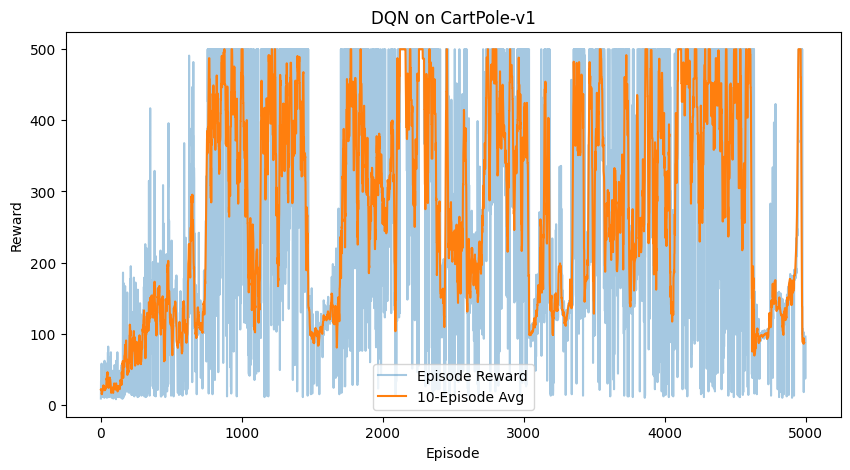

In [8]:
plt.figure(figsize=(10,5))
plt.plot(rewards, alpha=0.4, label="Episode Reward")
plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label="10-Episode Avg")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN on CartPole-v1")
plt.legend()
plt.show()

In [9]:
def evaluate(policy_net, n_eval=10, render=False):
    env = gym.make(ENV_NAME, render_mode="human" if render else None)
    rewards = []
    for ep in range(n_eval):
        obs, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            with torch.no_grad():
                q_values = policy_net(torch.tensor([obs], dtype=torch.float32, device=DEVICE))
                action = int(torch.argmax(q_values))
            next_obs, reward, terminated, truncated, _ = env.step(action)
            obs = next_obs
            done = terminated or truncated
            total_reward += reward
        rewards.append(total_reward)
    env.close()
    print(f"Average reward over {n_eval} episodes: {np.mean(rewards):.2f}")
    return rewards

In [10]:
evaluate(policy_net, n_eval=10, render=False)

Average reward over 10 episodes: 94.20


[92.0, 92.0, 95.0, 91.0, 99.0, 96.0, 97.0, 93.0, 91.0, 96.0]